In [9]:
import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader

from transformers import PatchTSMixerConfig, PatchTSMixerForPrediction

import talib

In [10]:
TICKER = "AAPL"
START = "2020-01-01"
END   = None          # до текущей доступной даты
LOOKBACK = 128        # сколько дней истории подаем в модель
HORIZON  = 1          # сколько дней прогнозируем вперед
TRAIN_RATIO = 0.8

EPOCHS = 10
BATCH_SIZE = 64
LR = 3e-4
WEIGHT_DECAY = 1e-2
SEED = 42

In [11]:
def set_seed(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [12]:
set_seed(SEED)

In [13]:
df = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=True)
# auto_adjust=True -> цены скорректированы (дивиденды/сплиты), часто удобнее для ML
df = df.dropna() # type: ignore

[*********************100%***********************]  1 of 1 completed


In [14]:
df.shape

(1495, 5)

In [15]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.468262,72.528582,71.223259,71.476600,135480400
2020-01-03,71.763718,72.523746,71.539330,71.696160,146322800
2020-01-06,72.335564,72.374169,70.634547,70.885479,118387200
2020-01-07,71.995361,72.600968,71.775796,72.345212,108872000
2020-01-08,73.153511,73.455110,71.698596,71.698596,132079200


In [16]:
# берем один канал: Close
y = df["Close"].astype("float32").to_numpy()

In [19]:
# простая стандартизация по train-части (без утечки)
split = int(len(y) * TRAIN_RATIO)
train_y = y[:split]
mu, sigma = train_y.mean(), train_y.std() + 1e-8
y_norm = (y - mu) / sigma

In [20]:
def make_windows(series, lookback, horizon):
    X, Y, idx = [], [], []
    for i in range(lookback, len(series) - horizon + 1):
        X.append(series[i - lookback:i])
        Y.append(series[i:i + horizon])
        idx.append(i)
    X = np.asarray(X, dtype=np.float32)  # (N, lookback)
    Y = np.asarray(Y, dtype=np.float32)  # (N, horizon)
    idx = np.asarray(idx, dtype=np.int64)
    return X, Y, idx

In [21]:
X, Y, idx_y = make_windows(y_norm, LOOKBACK, HORIZON)

# X_train, Y_train = X[: split - LOOKBACK - HORIZON + 1], Y[: split - LOOKBACK - HORIZON + 1]
# X_test,  Y_test  = X[split - LOOKBACK:], Y[split - LOOKBACK:]
train_mask = idx_y < split
test_mask = idx_y >= split

X_train, Y_train = X[train_mask], Y[train_mask]
X_test, Y_test = X[test_mask], Y[test_mask]
idx_test = idx_y[test_mask]

In [22]:
X_train.shape

(1068, 128, 1)

## Обучение TSMixer в PyTorch

In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [26]:
train_ds = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(Y_train),
)
test_ds = TensorDataset(
    torch.from_numpy(X_test),
    torch.from_numpy(Y_test),
)

In [27]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, drop_last=False)

In [28]:
xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)

torch.Size([64, 128, 1]) torch.Size([64, 1, 1])


In [30]:
config = PatchTSMixerConfig(
    context_length=LOOKBACK,
    prediction_length=HORIZON,
    num_input_channels=1,
    patch_length=16,     # размер патча по времени
    patch_stride=8,      # шаг патчей
    d_model=64,
    num_layers=6,
    dropout=0.1,
)

In [31]:
model = PatchTSMixerForPrediction(config).to(device)

optim = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
loss_fn = torch.nn.MSELoss()

In [32]:
def evaluate():
    model.eval()
    losses = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)                       # (B, L, 1)
            yb = yb.to(device)                       # (B, H)
            out = model(past_values=xb)              # HF-style forward  [oai_citation:3‡Hugging Face](https://huggingface.co/docs/transformers/en/model_doc/patchtsmixer?utm_source=chatgpt.com)
            yhat = out.prediction_outputs            # (B, H) обычно
            loss = loss_fn(yhat, yb)
            losses.append(loss.item())
    return float(np.mean(losses))

In [33]:
for epoch in range(1, EPOCHS+1):
    model.train()
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        out = model(past_values=xb)
        yhat = out.prediction_outputs
        
        loss = loss_fn(yhat, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()
        optim.zero_grad(set_to_none=True)

    print(f"epoch={epoch:02d}  test_mse={evaluate():.5f}")

epoch=01  test_mse=0.05719
epoch=02  test_mse=0.06879
epoch=03  test_mse=0.04916
epoch=04  test_mse=0.04133
epoch=05  test_mse=0.03799
epoch=06  test_mse=0.03870
epoch=07  test_mse=0.03358
epoch=08  test_mse=0.02743
epoch=09  test_mse=0.02520
epoch=10  test_mse=0.02409


In [34]:
model.eval()
preds_norm = np.zeros(len(X_test), dtype=np.float32)

In [35]:
with torch.no_grad():
    for i in range(len(X_test)):
        xb = torch.from_numpy(X_test[i:i+1]).to(device)  # (1, L, 1)
        out = model(past_values=xb)
        yhat = out.prediction_outputs  # (1, 1, 1)
        preds_norm[i] = yhat.squeeze().item()

In [36]:
Y_test.shape

(299, 1, 1)


Walk-forward test metrics:
MSE : 46.193455
MAE : 5.088077
MAPE: 2.282%
Directional accuracy: 0.930

Naive baseline (predict next Close = today's Close):
MSE : 1070.288330
MAE : 26.263983


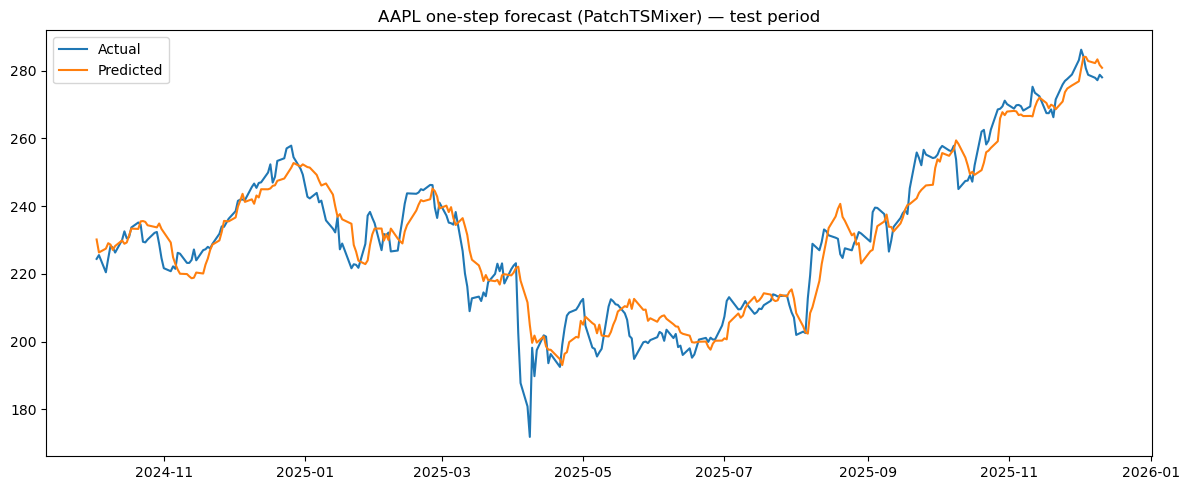

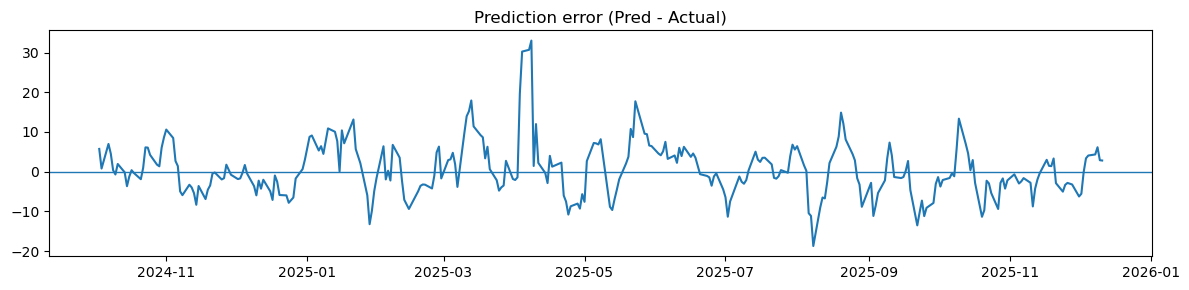

In [37]:
# Actual next-day closes for the same targets
actual_norm = Y_test.squeeze(-1).squeeze(-1)  # (N,)
# denormalize to prices
preds = preds_norm * sigma + mu
actual = actual_norm * sigma + mu

# Metrics
mse = float(np.mean((preds - actual) ** 2))
mae = float(np.mean(np.abs(preds - actual)))
mape = float(np.mean(np.abs((preds - actual) / (actual + 1e-8)))) * 100.0

# Directional accuracy: compare sign of (pred - prev_close) vs (actual - prev_close)
prev_close = y[idx_test - 1]  # close at time t-1 (decision time)
dir_pred = np.sign(preds - prev_close)
dir_true = np.sign(actual - prev_close)
dir_acc = float(np.mean(dir_pred == dir_true))

print("\nWalk-forward test metrics:")
print(f"MSE : {mse:.6f}")
print(f"MAE : {mae:.6f}")
print(f"MAPE: {mape:.3f}%")
print(f"Directional accuracy: {dir_acc:.3f}")

# Optional naive baseline: yhat = prev_close (persistence)
naive = prev_close
mse_naive = float(np.mean((naive - actual) ** 2))
mae_naive = float(np.mean(np.abs(naive - actual)))
print("\nNaive baseline (predict next Close = today's Close):")
print(f"MSE : {mse_naive:.6f}")
print(f"MAE : {mae_naive:.6f}")

# Plot prediction vs actual for test period
dates_test = df.index[idx_test]
plt.figure(figsize=(12, 5))
plt.plot(dates_test, actual, label="Actual")
plt.plot(dates_test, preds, label="Predicted")
plt.title(f"{TICKER} one-step forecast (PatchTSMixer) — test period")
plt.legend()
plt.tight_layout()
plt.show()

# Plot errors
plt.figure(figsize=(12, 3))
plt.plot(dates_test, preds - actual)
plt.title("Prediction error (Pred - Actual)")
plt.axhline(0.0, linewidth=1)
plt.tight_layout()
plt.show()

<div class="alert alert-warning">

<b>Отвратительно!</b>

Попробуем улучшить - добавим тех анализ
    
</div>

In [38]:
df.columns = ["Open", "High", "Low", "Close", "Volume"]

In [39]:
# Важно: TA-Lib ожидает 1D numpy массивы float
o = df['Open']
h = df['High']
l = df["Low"]
c = df["Close"]
v = df["Volume"]

In [40]:
# Примеры тех-индикаторов
df["rsi14"] = talib.RSI(c, timeperiod=14)

macd, macdsignal, macdhist = talib.MACD(c, fastperiod=12, slowperiod=26, signalperiod=9)
df["macd"] = macd
df["macd_signal"] = macdsignal
df["macd_hist"] = macdhist

df["atr14"] = talib.ATR(h, l, c, timeperiod=14)

upper, middle, lower = talib.BBANDS(c, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
df["bb_up"] = upper
df["bb_mid"] = middle
df["bb_low"] = lower

df["ema20"] = talib.EMA(c, timeperiod=20)
df["ema50"] = talib.EMA(c, timeperiod=50)

df["adx14"] = talib.ADX(h, l, c, timeperiod=14)
df["obv"] = talib.OBV(c, v)

# Нормализованные относительные фичи (обычно лучше абсолютных)
df["close_over_ema20"] = c / df["ema20"] - 1.0
df["close_over_ema50"] = c / df["ema50"] - 1.0
df["bb_pos"] = (c - df["bb_low"]) / (df["bb_up"] - df["bb_low"] + 1e-12)
df["atr_pct"] = df["atr14"] / c

# Убираем строки с NaN (индикаторы первые N дней будут NaN)
df = df.dropna().copy()

In [41]:
df.head()

,Open,High,Low,Close,Volume,rsi14,macd,macd_signal,macd_hist,atr14,...,bb_mid,bb_low,ema20,ema50,adx14,obv,close_over_ema20,close_over_ema50,bb_pos,atr_pct
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-13,67.227600,67.699214,61.176462,64.064179,370732000,40.358436,-2.783042,-2.055455,-0.727587,3.953634,...,70.420899,60.086996,69.322644,73.576709,29.172424,753418000.0,-0.075855,-0.129287,0.192434,0.061714
2020-03-16,58.578979,62.659018,58.044485,58.516096,322423600,34.401965,-3.289952,-2.302354,-0.987598,4.101210,...,69.419753,58.559527,68.293449,72.986097,30.059999,430994400.0,-0.143167,-0.198257,-0.002000,0.070087
2020-03-17,61.154694,62.303487,57.657512,59.860784,324056000,36.835249,-3.542343,-2.550352,-0.991991,4.140122,...,68.599271,57.457451,67.490338,72.471379,30.943733,755050400.0,-0.113047,-0.174008,0.107852,0.069163
2020-03-18,59.657631,60.462999,57.347944,57.988854,300233600,34.894744,-3.849044,-2.810090,-1.038953,4.066903,...,67.629081,56.340743,66.585434,71.903437,31.814305,454816800.0,-0.129106,-0.193518,0.073001,0.070132
2020-03-19,59.200520,61.149846,58.675701,59.831753,271857200,38.338722,-3.898461,-3.027764,-0.870696,4.002195,...,66.719233,56.012017,65.942227,71.430037,32.334253,726674000.0,-0.092664,-0.162373,0.178372,0.066891


In [42]:
FEATURES = [
    "Close", "Volume",
    "rsi14", "macd", "macd_signal", "macd_hist",
    "atr_pct", "adx14", "obv",
    "close_over_ema20", "close_over_ema50",
    "bb_pos",
]

# Target: next-day Close
df["y_next_close"] = df["Close"].shift(-1)
df = df.iloc[:-1].copy()

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["y_next_close"]).copy()

X_raw = df[FEATURES].astype("float32").to_numpy()
y_raw = df["Close"].astype("float32").to_numpy()  # следующий Close

In [43]:
# Time split без утечки
split = int(len(X_raw) * TRAIN_RATIO)
X_train_raw, X_test_raw = X_raw[:split], X_raw[split:]
y_train_raw, y_test_raw = y_raw[:split], y_raw[split:]

In [44]:
def make_windows_multivar(Xn, yn, lookback):
    Xw, Yw, idx_t = [], [], []
    for i in range(lookback, len(yn)):
        Xw.append(Xn[i - lookback:i, :])  # (L, C)
        Yw.append(yn[i]) 
        idx_t.append(i)
    Xw = np.asarray(Xw, dtype=np.float32)         # (N, L, C)
    Yw = np.asarray(Yw, dtype=np.float32)[:, None]  # (N, 1)
    idx_t = np.asarray(idx_t, dtype=np.int64)
    return Xw, Yw, idx_t

In [46]:
# Normalize using train only
mu_x = X_raw[:split].mean(axis=0, keepdims=True)
sd_x = X_raw[:split].std(axis=0, keepdims=True) + 1e-8
Xn = (X_raw - mu_x) / sd_x

mu_y = float(y_raw[:split].mean())
sd_y = float(y_raw[:split].std() + 1e-8)
yn = (y_raw - mu_y) / sd_y

# Windowing
Xw, Yw, idx_t = make_windows_multivar(Xn, yn, LOOKBACK)

In [47]:
Xw.shape, Yw.shape

((1317, 128, 12), (1317, 1))

In [48]:
split_w = split - LOOKBACK

if split_w <= 0 or split_w >= len(Xw):
    raise RuntimeError(
        f"Bad split: split_w={split_w}, len(Xw)={len(Xw)}. "
        f"Check LOOKBACK={LOOKBACK} and data length={len(df)}."
    )

X_train, Y_train, idx_train = Xw[:split_w], Yw[:split_w], idx_t[:split_w]
X_test,  Y_test,  idx_test  = Xw[split_w:], Yw[split_w:], idx_t[split_w:]

In [49]:
print("Shapes:")
print("  X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("  X_test :", X_test.shape,  "Y_test :", Y_test.shape)

Shapes:
  X_train: (1028, 128, 12) Y_train: (1028, 1)
  X_test : (289, 128, 12) Y_test : (289, 1)


In [51]:
print("X_test finite:", np.isfinite(X_test).all())
print("Y_test finite:", np.isfinite(Y_test).all())

# если False — покажем где
bad_x = np.argwhere(~np.isfinite(X_test))
bad_y = np.argwhere(~np.isfinite(Y_test))
print("bad_x count:", len(bad_x), "example:", bad_x[:5])
print("bad_y count:", len(bad_y), "example:", bad_y[:5])

X_test finite: True
Y_test finite: True
bad_x count: 0 example: []
bad_y count: 0 example: []


In [52]:
train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test), torch.from_numpy(Y_test)),
    batch_size=256, shuffle=False
)

In [53]:

config = PatchTSMixerConfig(
    context_length=LOOKBACK,
    prediction_length=1,
    num_input_channels=len(FEATURES),
    patch_length=16,
    patch_stride=8,
    d_model=96,
    num_layers=6,
    dropout=0.1,
)

In [54]:
model = PatchTSMixerForPrediction(config).to(device)

In [55]:
optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn = torch.nn.MSELoss()

In [56]:
TARGET_CHANNEL = FEATURES.index("Close")  # будет 0

In [57]:
def evaluate_batch_mse():
    model.eval()
    losses = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)          # (B,1)
            out = model(past_values=xb)
            yhat = out.prediction_outputs  # (B, 1, 12)
            yhat = yhat[:, :, TARGET_CHANNEL]  # -> (B, 1)
            loss = loss_fn(yhat, yb)
            losses.append(loss_fn(yhat, yb).item())
    return float(np.mean(losses))

In [58]:
for epoch in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        out = model(past_values=xb)
        yhat = out.prediction_outputs  # (B, 1, 12)
        yhat = yhat[:, :, TARGET_CHANNEL]  # -> (B, 1)
        loss = loss_fn(yhat, yb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()
        optim.zero_grad(set_to_none=True)

    test_mse = evaluate_batch_mse()
    print(f"epoch={epoch:02d} test_mse_norm={test_mse:.6f}")

epoch=01 test_mse_norm=0.093663
epoch=02 test_mse_norm=0.070360
epoch=03 test_mse_norm=0.052448
epoch=04 test_mse_norm=0.039108
epoch=05 test_mse_norm=0.039750
epoch=06 test_mse_norm=0.030813
epoch=07 test_mse_norm=0.026611
epoch=08 test_mse_norm=0.024142
epoch=09 test_mse_norm=0.024556
epoch=10 test_mse_norm=0.028117


In [59]:
# Walk-forward over whole test period
model.eval()
preds_norm = []
with torch.no_grad():
    for xb, _ in DataLoader(TensorDataset(torch.from_numpy(X_test), torch.from_numpy(Y_test)),
                            batch_size=256, shuffle=False):
        xb = xb.to(device)
        out = model(past_values=xb)
        yhat = out.prediction_outputs  # (B, 1, 12)
        yhat = yhat[:, :, TARGET_CHANNEL]  # -> (B, 1)
        preds_norm.append(yhat.cpu().numpy())

In [60]:
df.head()

,Open,High,Low,Close,Volume,rsi14,macd,macd_signal,macd_hist,atr14,...,bb_low,ema20,ema50,adx14,obv,close_over_ema20,close_over_ema50,bb_pos,atr_pct,y_next_close
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-13,67.227600,67.699214,61.176462,64.064179,370732000,40.358436,-2.783042,-2.055455,-0.727587,3.953634,...,60.086996,69.322644,73.576709,29.172424,753418000.0,-0.075855,-0.129287,0.192434,0.061714,58.516096
2020-03-16,58.578979,62.659018,58.044485,58.516096,322423600,34.401965,-3.289952,-2.302354,-0.987598,4.101210,...,58.559527,68.293449,72.986097,30.059999,430994400.0,-0.143167,-0.198257,-0.002000,0.070087,59.860784
2020-03-17,61.154694,62.303487,57.657512,59.860784,324056000,36.835249,-3.542343,-2.550352,-0.991991,4.140122,...,57.457451,67.490338,72.471379,30.943733,755050400.0,-0.113047,-0.174008,0.107852,0.069163,57.988854
2020-03-18,59.657631,60.462999,57.347944,57.988854,300233600,34.894744,-3.849044,-2.810090,-1.038953,4.066903,...,56.340743,66.585434,71.903437,31.814305,454816800.0,-0.129106,-0.193518,0.073001,0.070132,59.831753
2020-03-19,59.200520,61.149846,58.675701,59.831753,271857200,38.338722,-3.898461,-3.027764,-0.870696,4.002195,...,56.012017,65.942227,71.430037,32.334253,726674000.0,-0.092664,-0.162373,0.178372,0.066891,59.780980


In [61]:
close_today = df["Close"].astype("float32").to_numpy()
preds_norm = np.concatenate(preds_norm, axis=0).reshape(-1)
true_norm = Y_test.reshape(-1)

preds_price = preds_norm * sd_y + mu_y
true_price = true_norm * sd_y + mu_y

close_today_test = close_today[idx_test].astype(np.float64)

dir_pred = np.sign(preds_price - close_today_test)

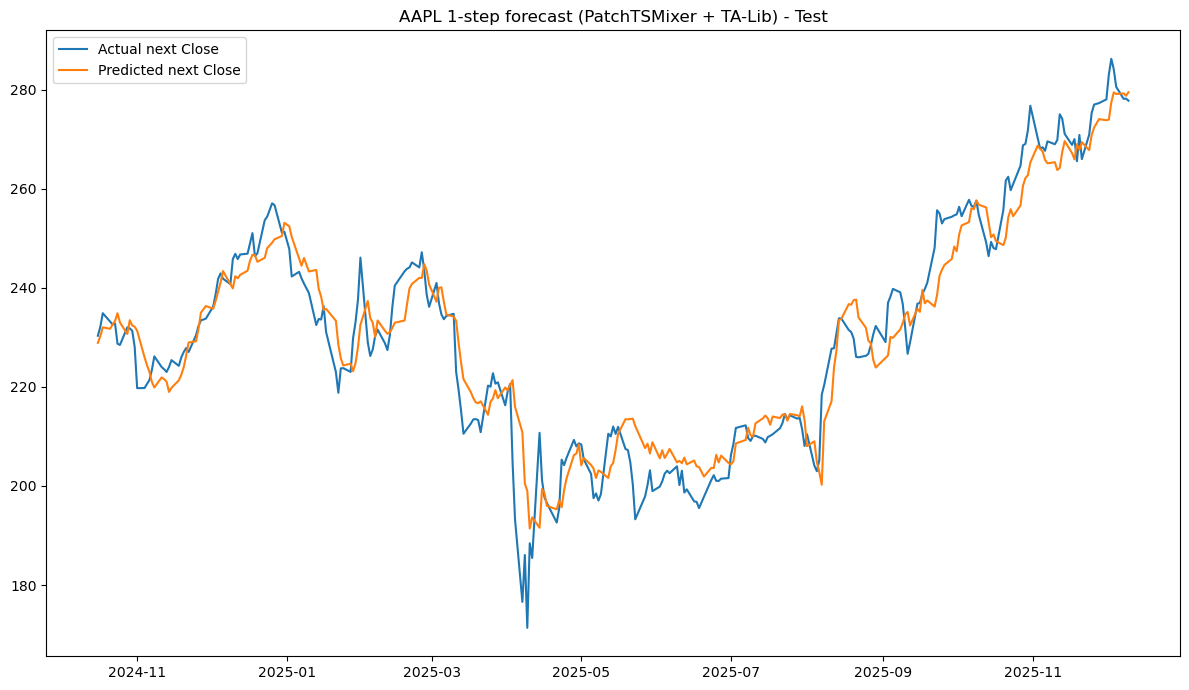

In [62]:
test_dates = df.index[idx_test]
plt.figure(figsize=(12, 7))
plt.plot(test_dates, true_price, label="Actual next Close")
plt.plot(test_dates, preds_price, label="Predicted next Close")
plt.title(f"{TICKER} 1-step forecast (PatchTSMixer + TA-Lib) - Test")
plt.legend()
plt.tight_layout()
plt.show()

## Бинарная классификация с использованием стандартных классов transformers

В этом разделе мы переделываем задачу прогнозирования на **бинарную классификацию направления движения цены**.

### Ключевые отличия от предыдущего подхода:

1. **Используем стандартный `PatchTSMixerForPrediction`** из библиотеки transformers как backbone
2. **Добавляем classification head** поверх prediction outputs
3. **Устанавливаем `prediction_length=1`** чтобы получить компактное представление признаков
4. **Обучаем на бинарные метки**: 0 = падение, 1 = рост

In [63]:
# Шаг 1: Подготовка данных для бинарной классификации
# ======================================================

# Копируем DataFrame с техническими индикаторами
df_binary = df.copy()

# Создаем бинарный таргет: 1 если цена завтра выше сегодняшней, иначе 0
df_binary["target"] = (df_binary["y_next_close"] > df_binary["Close"]).astype(int)

# Убираем NaN значения
df_binary = df_binary.dropna(subset=["target"]).copy()

print("=" * 70)
print("РАСПРЕДЕЛЕНИЕ КЛАССОВ")
print("=" * 70)
print(df_binary["target"].value_counts().sort_index())
print(f"\nБаланс классов (доля класса 1): {df_binary['target'].mean():.3f}")
print(f"Всего примеров: {len(df_binary)}")
print("=" * 70)

РАСПРЕДЕЛЕНИЕ КЛАССОВ
target
0    665
1    780
Name: count, dtype: int64

Баланс классов (доля класса 1): 0.540
Всего примеров: 1445


In [64]:
# 2: Нормализация и создание временных окон
# ================================================

# Извлекаем признаки и таргет
X_binary = df_binary[FEATURES].astype("float32").to_numpy()
y_binary = df_binary["target"].astype("int64").to_numpy()

# Time-based split (без утечки данных из будущего)
split_binary = int(len(X_binary) * TRAIN_RATIO)

# Нормализация признаков (только по train!)
mu_binary = X_binary[:split_binary].mean(axis=0, keepdims=True)
sd_binary = X_binary[:split_binary].std(axis=0, keepdims=True) + 1e-8
X_binary_norm = (X_binary - mu_binary) / sd_binary

# Функция для создания скользящих окон
def create_classification_windows(X_normalized, y_labels, lookback):
    """
    Создает скользящие окна для задачи классификации временных рядов.
    
    Параметры:
    - X_normalized: нормализованные признаки (T, num_features)
    - y_labels: метки классов (T,)
    - lookback: размер окна истории
    
    Возвращает:
    - X_windows: (N, lookback, num_features)
    - y_windows: (N,)
    - indices: индексы в оригинальном массиве
    """
    X_windows, y_windows, indices = [], [], []
    
    for i in range(lookback, len(y_labels)):
        # Берем окно истории размером lookback
        X_windows.append(X_normalized[i - lookback:i, :])
        # Таргет - это метка в момент времени i
        y_windows.append(y_labels[i])
        indices.append(i)
    
    X_windows = np.asarray(X_windows, dtype=np.float32)  # (N, lookback, num_features)
    y_windows = np.asarray(y_windows, dtype=np.int64)     # (N,)
    indices = np.asarray(indices, dtype=np.int64)
    
    return X_windows, y_windows, indices

# Создаем окна
X_win, y_win, idx_win = create_classification_windows(X_binary_norm, y_binary, LOOKBACK)

print(f"Размер окон признаков: {X_win.shape}")
print(f"Размер таргетов: {y_win.shape}")
print(f"Размер индексов: {idx_win.shape}")

Размер окон признаков: (1317, 128, 12)
Размер таргетов: (1317,)
Размер индексов: (1317,)


In [65]:
# 3: Разделение на train/test
# ==================================

# Вычисляем границу разделения с учетом окон
split_w_binary = split_binary - LOOKBACK

# Проверка корректности split
if split_w_binary <= 0 or split_w_binary >= len(X_win):
    raise RuntimeError(
        f"Некорректный split: split_w_binary={split_w_binary}, len(X_win)={len(X_win)}. "
        f"Проверьте LOOKBACK={LOOKBACK} и размер данных={len(df_binary)}."
    )

# Разделяем данные
X_train_binary = X_win[:split_w_binary]
y_train_binary = y_win[:split_w_binary]
idx_train_binary = idx_win[:split_w_binary]

X_test_binary = X_win[split_w_binary:]
y_test_binary = y_win[split_w_binary:]
idx_test_binary = idx_win[split_w_binary:]

print("=" * 70)
print("РАЗМЕРЫ ВЫБОРОК")
print("=" * 70)
print(f"Train: X={X_train_binary.shape}, y={y_train_binary.shape}")
print(f"Test:  X={X_test_binary.shape}, y={y_test_binary.shape}")
print(f"\nРаспределение классов в test:")
print(f"  Класс 0 (падение): {(y_test_binary == 0).sum()} ({(y_test_binary == 0).mean():.1%})")
print(f"  Класс 1 (рост):    {(y_test_binary == 1).sum()} ({(y_test_binary == 1).mean():.1%})")
print("=" * 70)

РАЗМЕРЫ ВЫБОРОК
Train: X=(1028, 128, 12), y=(1028,)
Test:  X=(289, 128, 12), y=(289,)

Распределение классов в test:
  Класс 0 (падение): 127 (43.9%)
  Класс 1 (рост):    162 (56.1%)


In [66]:
# 4: Создание DataLoaders
# =============================

train_dataset_binary = TensorDataset(
    torch.from_numpy(X_train_binary),
    torch.from_numpy(y_train_binary)
)

test_dataset_binary = TensorDataset(
    torch.from_numpy(X_test_binary),
    torch.from_numpy(y_test_binary)
)

train_loader_binary = DataLoader(
    train_dataset_binary,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False
)

test_loader_binary = DataLoader(
    test_dataset_binary,
    batch_size=256,
    shuffle=False,
    drop_last=False
)

print(f"Train batches: {len(train_loader_binary)}")
print(f"Test batches:  {len(test_loader_binary)}")

# Проверим размерность одного батча
xb_sample, yb_sample = next(iter(train_loader_binary))
print(f"\nПример батча:")
print(f"  X: {xb_sample.shape}  (batch, lookback, num_features)")
print(f"  y: {yb_sample.shape}  (batch,)")

Train batches: 17
Test batches:  2

Пример батча:
  X: torch.Size([64, 128, 12])  (batch, lookback, num_features)
  y: torch.Size([64])  (batch,)


In [67]:
# 5: Определение модели классификации
# ==========================================

import torch.nn as nn
from transformers import PatchTSMixerForPrediction

class TSMixerBinaryClassifier(nn.Module):
    """
    Бинарный классификатор на основе PatchTSMixer.
    
    Архитектура:
    1. Backbone: стандартный PatchTSMixerForPrediction из HuggingFace
    2. Feature extraction: используем prediction_outputs как признаки
    3. Classification head: полносвязные слои с dropout
    
    Преимущества:
    - Используем проверенную архитектуру из transformers
    - Backbone уже оптимизирован для работы с временными рядами
    - Простота и прозрачность кода
    """
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        # Backbone: стандартная модель PatchTSMixer для prediction
        # Она обучается предсказывать следующий шаг, и мы используем её выходы как признаки
        self.backbone = PatchTSMixerForPrediction(config)
        
        # Classification head
        # Входные признаки: (batch, prediction_length=1, num_channels)
        # После flatten: (batch, num_channels)
        self.classifier = nn.Sequential(
            nn.Flatten(),  # (batch, 1, num_channels) -> (batch, num_channels)
            nn.Linear(config.num_input_channels, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)  # 2 класса: падение (0) и рост (1)
        )
    
    def forward(self, past_values):
        """
        Forward pass.
        
        Параметры:
        - past_values: (batch, context_length, num_channels)
        
        Возвращает:
        - logits: (batch, 2) - логиты для двух классов
        """
        # Получаем prediction outputs из backbone
        outputs = self.backbone(past_values=past_values)
        
        # prediction_outputs имеет размер (batch, prediction_length=1, num_channels)
        # Эти выходы содержат закодированную информацию о временном ряде
        features = outputs.prediction_outputs
        
        # Пропускаем через classification head
        logits = self.classifier(features)
        
        return logits

print("Класс TSMixerBinaryClassifier определен")

Класс TSMixerBinaryClassifier определен


In [68]:
# 6: Создание и инициализация модели
# ========================================

# Конфигурация модели
# ВАЖНО: prediction_length=1, так как мы используем выход как feature vector
config_binary = PatchTSMixerConfig(
    context_length=LOOKBACK,          # Длина входного окна
    prediction_length=1,              # Выход размером 1 (используется как признаки)
    num_input_channels=len(FEATURES), # Количество признаков (12)
    patch_length=16,                  # Размер патча
    patch_stride=8,                   # Шаг между патчами
    d_model=96,                       # Размерность скрытого представления
    num_layers=6,                     # Количество слоев
    dropout=0.1,                      # Dropout для регуляризации
)

# Создаем модель
model_binary = TSMixerBinaryClassifier(config_binary).to(device)

# Считаем количество параметров
total_params = sum(p.numel() for p in model_binary.parameters())
trainable_params = sum(p.numel() for p in model_binary.parameters() if p.requires_grad)

print("=" * 70)
print("ИНФОРМАЦИЯ О МОДЕЛИ")
print("=" * 70)
print(f"Всего параметров:      {total_params:,}")
print(f"Обучаемых параметров:  {trainable_params:,}")
print(f"Устройство:            {device}")
print("=" * 70)

ИНФОРМАЦИЯ О МОДЕЛИ
Всего параметров:      301,321
Обучаемых параметров:  301,321
Устройство:            cpu


In [69]:
# 7: Настройка обучения
# ===========================

# Optimizer: AdamW с weight decay для регуляризации
optimizer_binary = torch.optim.AdamW(
    model_binary.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# Loss function: CrossEntropyLoss для бинарной классификации
criterion_binary = nn.CrossEntropyLoss()

# Функция для evaluation
def evaluate_binary_classifier():
    """
    Оценка модели на test set.
    
    Возвращает:
    - accuracy: точность классификации
    - predictions: предсказанные метки
    - true_labels: истинные метки
    """
    model_binary.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for xb, yb in test_loader_binary:
            xb = xb.to(device)
            yb = yb.to(device)
            
            # Forward pass
            logits = model_binary(xb)
            
            # Предсказания (argmax по логитам)
            preds = torch.argmax(logits, dim=1)
            
            # Сохраняем для подсчета метрик
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    accuracy = (all_preds == all_labels).mean()
    
    return accuracy, all_preds, all_labels

print("✓ Optimizer, loss function и evaluation function настроены")

✓ Optimizer, loss function и evaluation function настроены


In [70]:
# 8: Обучение модели
# ========================

print("=" * 70)
print("НАЧАЛО ОБУЧЕНИЯ")
print("=" * 70)

for epoch in range(1, EPOCHS + 1):
    # Training phase
    model_binary.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0
    
    for xb, yb in train_loader_binary:
        xb = xb.to(device)
        yb = yb.to(device)
        
        # Forward pass
        logits = model_binary(xb)
        loss = criterion_binary(logits, yb)
        
        # Backward pass
        optimizer_binary.zero_grad(set_to_none=True)
        loss.backward()
        
        # Gradient clipping для стабильности
        torch.nn.utils.clip_grad_norm_(model_binary.parameters(), max_norm=1.0)
        
        # Update weights
        optimizer_binary.step()
        
        # Статистика
        train_loss_sum += loss.item()
        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == yb).sum().item()
        train_total += yb.size(0)
    
    # Метрики за эпоху
    train_loss_avg = train_loss_sum / len(train_loader_binary)
    train_acc = train_correct / train_total
    
    # Evaluation на test set
    test_acc, _, _ = evaluate_binary_classifier()
    
    # Вывод результатов
    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss_avg:.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Test Acc: {test_acc:.4f}")

print("=" * 70)
print("ОБУЧЕНИЕ ЗАВЕРШЕНО")
print("=" * 70)

НАЧАЛО ОБУЧЕНИЯ
Epoch  1/10 | Train Loss: 0.6978 | Train Acc: 0.4883 | Test Acc: 0.4394
Epoch  2/10 | Train Loss: 0.6943 | Train Acc: 0.4990 | Test Acc: 0.5260
Epoch  3/10 | Train Loss: 0.6937 | Train Acc: 0.5302 | Test Acc: 0.5571
Epoch  4/10 | Train Loss: 0.6916 | Train Acc: 0.5088 | Test Acc: 0.5467
Epoch  5/10 | Train Loss: 0.6886 | Train Acc: 0.5253 | Test Acc: 0.5606
Epoch  6/10 | Train Loss: 0.6877 | Train Acc: 0.5447 | Test Acc: 0.5606
Epoch  7/10 | Train Loss: 0.6880 | Train Acc: 0.5292 | Test Acc: 0.5502
Epoch  8/10 | Train Loss: 0.6936 | Train Acc: 0.5370 | Test Acc: 0.5467
Epoch  9/10 | Train Loss: 0.6882 | Train Acc: 0.5506 | Test Acc: 0.5502
Epoch 10/10 | Train Loss: 0.6809 | Train Acc: 0.5467 | Test Acc: 0.5467
ОБУЧЕНИЕ ЗАВЕРШЕНО


In [71]:
# 9: Финальная оценка и детальные метрики
# ==============================================

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Получаем финальные предсказания
final_test_acc, y_pred_binary, y_true_binary = evaluate_binary_classifier()

print("\n" + "=" * 70)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ")
print("=" * 70)
print(f"Test Accuracy: {final_test_acc:.4f} ({final_test_acc*100:.2f}%)")

# Baseline - всегда предсказываем мажоритарный класс
baseline_acc = max(y_true_binary.mean(), 1 - y_true_binary.mean())
print(f"Baseline (majority class): {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"Улучшение над baseline: {(final_test_acc - baseline_acc)*100:.2f}%")

# Classification Report
print("\n" + "-" * 70)
print("CLASSIFICATION REPORT")
print("-" * 70)
print(classification_report(
    y_true_binary,
    y_pred_binary,
    target_names=['Down (0)', 'Up (1)'],
    digits=4
))

# Confusion Matrix
print("-" * 70)
print("CONFUSION MATRIX")
print("-" * 70)
cm = confusion_matrix(y_true_binary, y_pred_binary)
print("\n              Predicted")
print("                0      1")
print(f"Actual 0    {cm[0,0]:5d}  {cm[0,1]:5d}")
print(f"       1    {cm[1,0]:5d}  {cm[1,1]:5d}")

# Дополнительные метрики
tn, fp, fn, tp = cm.ravel()
precision_up = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_up = tp / (tp + fn) if (tp + fn) > 0 else 0
precision_down = tn / (tn + fn) if (tn + fn) > 0 else 0
recall_down = tn / (tn + fp) if (tn + fp) > 0 else 0

print("\n" + "-" * 70)
print("ИНТЕРПРЕТАЦИЯ")
print("-" * 70)
print(f"True Positives (правильно предсказан рост):     {tp}")
print(f"True Negatives (правильно предсказано падение): {tn}")
print(f"False Positives (ложный сигнал на рост):        {fp}")
print(f"False Negatives (пропущенный рост):             {fn}")


ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ
Test Accuracy: 0.5467 (54.67%)
Baseline (majority class): 0.5606 (56.06%)
Улучшение над baseline: -1.38%

----------------------------------------------------------------------
CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Down (0)     0.3000    0.0236    0.0438       127
      Up (1)     0.5556    0.9568    0.7029       162

    accuracy                         0.5467       289
   macro avg     0.4278    0.4902    0.3734       289
weighted avg     0.4433    0.5467    0.4133       289

----------------------------------------------------------------------
CONFUSION MATRIX
----------------------------------------------------------------------

              Predicted
                0      1
Actual 0        3    124
       1        7    155

----------------------------------------------------------------------
ИНТЕРПРЕТАЦИЯ
----------------------

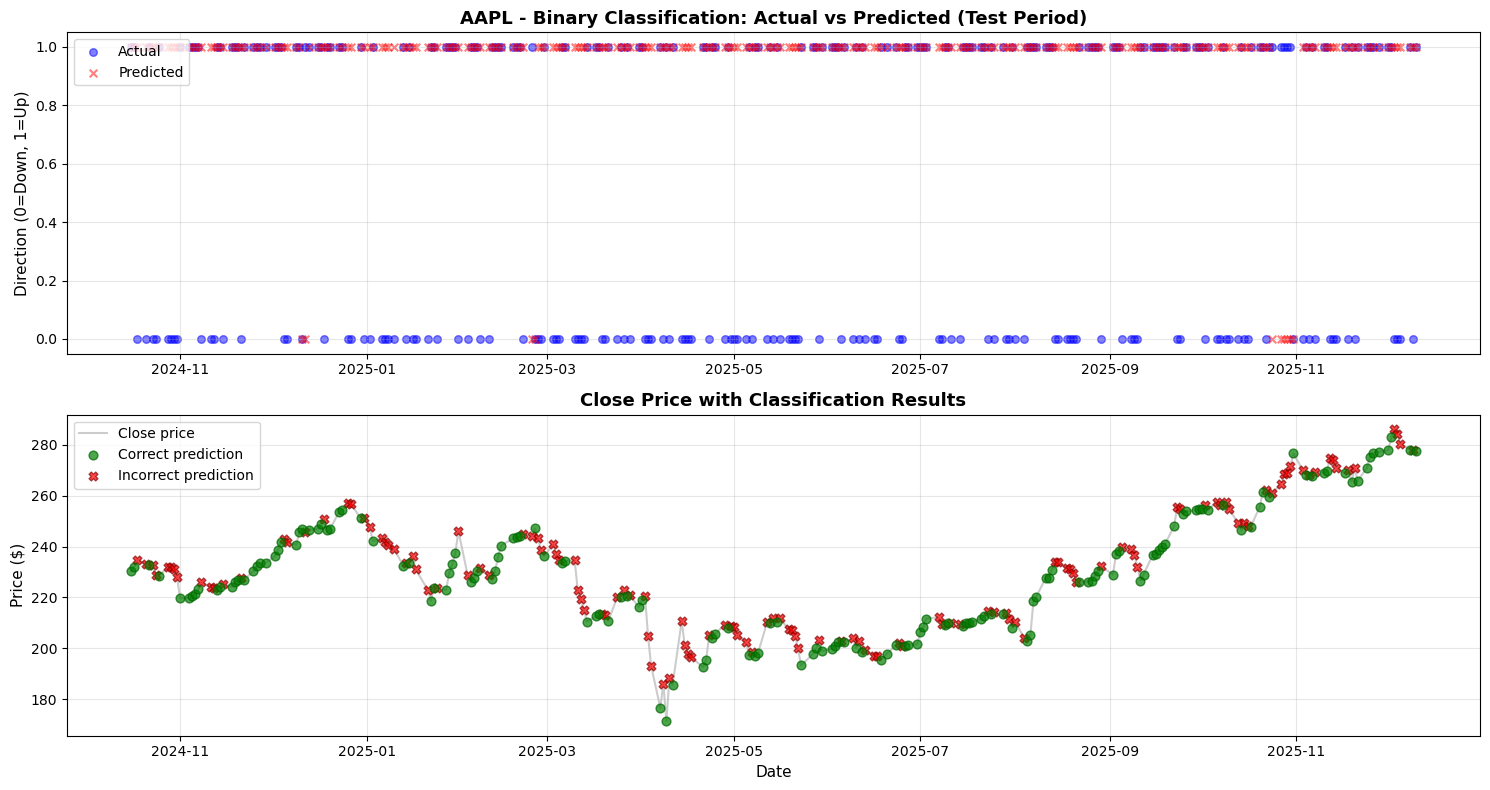


Правильных предсказаний: 158 (54.7%)
Неправильных предсказаний: 131 (45.3%)


In [72]:
# 10: Визуализация результатов
# ==================================

test_dates_binary = df_binary.index[idx_test_binary]

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# График 1: Предсказания vs Факт
axes[0].scatter(test_dates_binary, y_true_binary, 
               c='blue', alpha=0.5, label='Actual', marker='o', s=30)
axes[0].scatter(test_dates_binary, y_pred_binary, 
               c='red', alpha=0.5, label='Predicted', marker='x', s=30)
axes[0].set_ylabel('Direction (0=Down, 1=Up)', fontsize=11)
axes[0].set_title(f'{TICKER} - Binary Classification: Actual vs Predicted (Test Period)', 
                 fontsize=13, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# График 2: Цена с раскраской по предсказаниям
close_prices_test = df_binary["Close"].iloc[idx_test_binary].values

# Маски для правильных и неправильных предсказаний
correct_pred_mask = (y_pred_binary == y_true_binary)
incorrect_pred_mask = ~correct_pred_mask

# Линия цены
axes[1].plot(test_dates_binary, close_prices_test, 
            c='gray', alpha=0.4, linewidth=1.5, label='Close price', zorder=1)

# Правильные предсказания
axes[1].scatter(test_dates_binary[correct_pred_mask], 
               close_prices_test[correct_pred_mask],
               c='green', alpha=0.7, s=40, label='Correct prediction', 
               marker='o', edgecolors='darkgreen', linewidths=1, zorder=3)

# Неправильные предсказания
axes[1].scatter(test_dates_binary[incorrect_pred_mask], 
               close_prices_test[incorrect_pred_mask],
               c='red', alpha=0.7, s=40, label='Incorrect prediction', 
               marker='X', edgecolors='darkred', linewidths=1, zorder=2)

axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Price ($)', fontsize=11)
axes[1].set_title('Close Price with Classification Results', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nПравильных предсказаний: {correct_pred_mask.sum()} ({correct_pred_mask.mean()*100:.1f}%)")
print(f"Неправильных предсказаний: {incorrect_pred_mask.sum()} ({incorrect_pred_mask.mean()*100:.1f}%)")


BACKTEST ТОРГОВЫХ СТРАТЕГИЙ
Buy & Hold:               21.19%
Strategy (Long only):     17.41%
Strategy (Long/Short):    13.53%

Sharpe Ratio (годовой):
  Buy & Hold:           0.678
  Strategy (Long only): 0.595
  Strategy (Long/Short):0.502


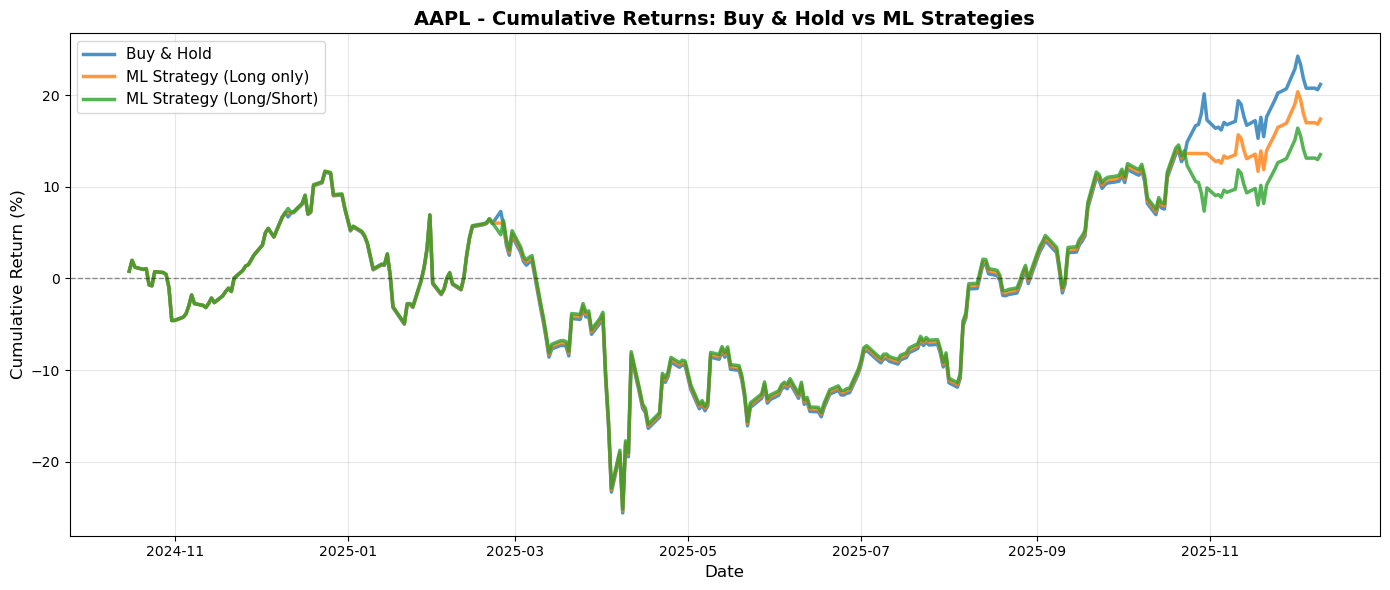


⚠️  ВАЖНО: Результаты не учитывают комиссии, проскальзывание и транзакционные издержки.


In [73]:
# 11: Бэктест торговых стратегий
# ====================================

# Рассчитаем реальные returns
actual_returns_binary = np.zeros(len(y_true_binary))

for i in range(len(idx_test_binary)):
    idx = idx_test_binary[i]
    if idx < len(df_binary):
        today_price = df_binary["Close"].iloc[idx]
        next_price = df_binary["y_next_close"].iloc[idx]
        actual_returns_binary[i] = (next_price - today_price) / today_price

# Стратегия 1: Long only (покупаем только когда модель предсказывает рост)
strategy_long_only = np.where(y_pred_binary == 1, actual_returns_binary, 0.0)

# Стратегия 2: Long/Short (лонг при росте, шорт при падении)
strategy_long_short = np.where(y_pred_binary == 1, actual_returns_binary, -actual_returns_binary)

# Кумулятивные доходности
cum_return_buy_hold = np.cumprod(1 + actual_returns_binary) - 1
cum_return_long_only = np.cumprod(1 + strategy_long_only) - 1
cum_return_long_short = np.cumprod(1 + strategy_long_short) - 1

# Статистика
print("\n" + "=" * 70)
print("BACKTEST ТОРГОВЫХ СТРАТЕГИЙ")
print("=" * 70)
print(f"Buy & Hold:              {cum_return_buy_hold[-1]:7.2%}")
print(f"Strategy (Long only):    {cum_return_long_only[-1]:7.2%}")
print(f"Strategy (Long/Short):   {cum_return_long_short[-1]:7.2%}")
print("=" * 70)

# Дополнительные метрики
sharpe_bh = actual_returns_binary.mean() / (actual_returns_binary.std() + 1e-8) * np.sqrt(252)
sharpe_long = strategy_long_only.mean() / (strategy_long_only.std() + 1e-8) * np.sqrt(252)
sharpe_ls = strategy_long_short.mean() / (strategy_long_short.std() + 1e-8) * np.sqrt(252)

print(f"\nSharpe Ratio (годовой):")
print(f"  Buy & Hold:           {sharpe_bh:.3f}")
print(f"  Strategy (Long only): {sharpe_long:.3f}")
print(f"  Strategy (Long/Short):{sharpe_ls:.3f}")
print("=" * 70)

# График кумулятивной доходности
plt.figure(figsize=(14, 6))
plt.plot(test_dates_binary, cum_return_buy_hold * 100, 
        label='Buy & Hold', linewidth=2.5, alpha=0.8)
plt.plot(test_dates_binary, cum_return_long_only * 100, 
        label='ML Strategy (Long only)', linewidth=2.5, alpha=0.8)
plt.plot(test_dates_binary, cum_return_long_short * 100, 
        label='ML Strategy (Long/Short)', linewidth=2.5, alpha=0.8)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.4, linewidth=1)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (%)', fontsize=12)
plt.title(f'{TICKER} - Cumulative Returns: Buy & Hold vs ML Strategies', 
         fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n⚠️  ВАЖНО: Результаты не учитывают комиссии, проскальзывание и транзакционные издержки.")